In [1]:
import os
cwd = os.getcwd()
print(f"{cwd=}")
if (cwd.endswith('tests')):
    os.chdir("../")
    print(f"{os.getcwd()=}")

cwd='d:\\Bibliotheken\\Dokumente\\_Uni\\02_Semester 2\\Python & Akustik\\Ambisonics Player\\ambisonics-player\\tests'
os.getcwd()='d:\\Bibliotheken\\Dokumente\\_Uni\\02_Semester 2\\Python & Akustik\\Ambisonics Player\\ambisonics-player'


**My own MAGLS Implementation**

In [2]:
from hrtf import HRTF
from spherical import SphericalHarmonics

import matplotlib.pyplot as plt
import numpy as np
import pyfar as pf

ambi_order = 3
# create our own spherical harmonics
hrtf = HRTF()
sh = SphericalHarmonics(hrtf, ambi_order=ambi_order)

my_own_magls = pf.Signal(sh.hrir_nm, sh.sampling_rate)


Loaded HRTF from file: D:\Bibliotheken\Dokumente\_Uni\02_Semester 2\Python & Akustik\Ambisonics Player\ambisonics-player\FABIAN_HRIR_measured_HATO_0.sofa
Using MagLS HRTF Preprocessing
Convert to Spherical Harmonic Signal


d:\Bibliotheken\Dokumente\_Uni\02_Semester 2\Python & Akustik\Ambisonics Player\ambisonics-player\spherical.py:206: UserWarning: Gimbal lock detected. Setting third angle to zero since it is not possible to uniquely determine all angles.
  alpha, beta, gamma = rotation.as_euler("zyz")


Setting up Spherical Harmonics took 2.49s


**Pyshroom MagLS implementation**

In [3]:
from shroom.acoustics.hrtf_processing import magls_hrtf
from shroom.acoustics.spatial_signal import SpatialSignal
import shroom.utils.sofa as sofa

ss = sofa.load_sofa(hrtf.DEFAULT_HRTF_FILE)
shroom_magls = magls_hrtf(ss, ambi_order)

In [4]:
def visualize_time(freq, signal: pf.Signal | np.ndarray, title: str, n_channels=None):
    # time representation of pyfar signa
    if isinstance(signal, pf.Signal):
        array = signal.time
    else:
        array = signal

    if n_channels is None:
        n = array.shape[0]
    else:
        n = min(array.shape[0], n_channels)
        
    # plot all graphs
    for i in range(n):
        plt.semilogx(freq, array[i])

    # plt.legend(labels, loc='lower left')
    plt.title(title)
    plt.xlabel(r"Time")
    plt.ylabel(r"Amplitude")
    plt.xlim(0, 20e3)
    # plt.ylim(-100, 5)
    plt.xticks([100, 1e3, 10e3], ["100", "1k", "10k"])
    plt.grid(alpha=0.3, which='both')
    plt.show()

C:\Users\tesaf\AppData\Local\Temp\ipykernel_32180\415372261.py:21: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 20e3)


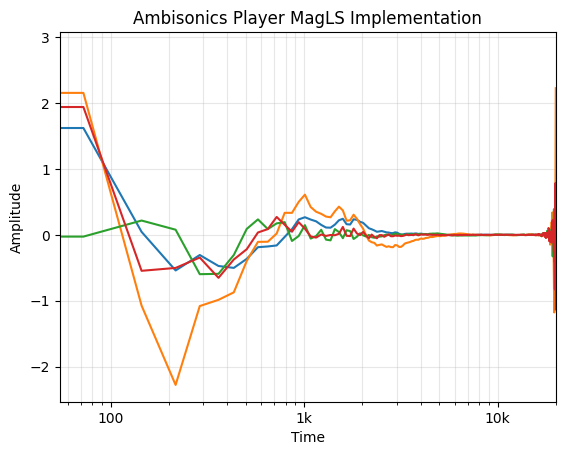

In [5]:
signal = my_own_magls[0]

# frequency axis
freq = np.linspace(0, 20001, my_own_magls.n_samples)

visualize_time(freq, signal, "Ambisonics Player MagLS Implementation", n_channels=4)

d:\Bibliotheken\Dokumente\_Uni\02_Semester 2\Python & Akustik\Ambisonics Player\ambisonics-player\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\Bibliotheken\Dokumente\_Uni\02_Semester 2\Python & Akustik\Ambisonics Player\ambisonics-player\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\tesaf\AppData\Local\Temp\ipykernel_32180\415372261.py:21: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 20e3)


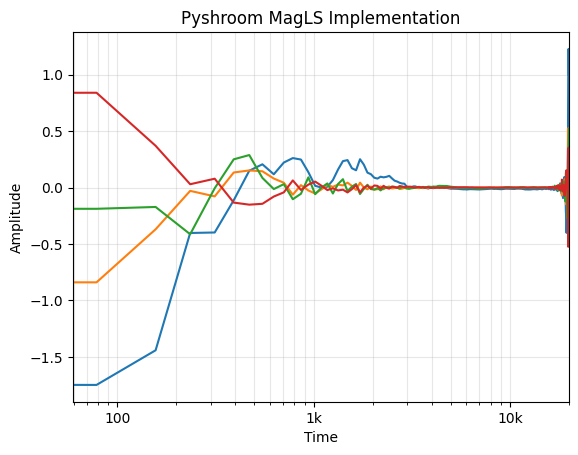

In [6]:
signal = shroom_magls.data[0]

# frequency axis
freq = np.linspace(0, 20001, shroom_magls.n_samples)

visualize_time(freq, signal, "Pyshroom MagLS Implementation", 4)